# Моделирование: бейзлайн, линейная модель, бустинг

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

from src.data import prepare
from src.features import FEATURE_COLUMNS, make_features
from src.model import train
from src.validation import backtest, baseline_predict, compare, evaluable, time_split

features = make_features(prepare(ROOT / "data" / "raw" / "guests.csv"))
train_df, valid_df = time_split(features, valid_weeks=6)
train_rows, valid_rows = evaluable(train_df), evaluable(valid_df)

print(f"Обучение: {train_rows['date'].min().date()} — {train_rows['date'].max().date()}, {len(train_rows)} дней")
print(f"Проверка: {valid_rows['date'].min().date()} — {valid_rows['date'].max().date()}, {len(valid_rows)} дней")

Обучение: 2024-10-01 — 2026-08-19, 1144 дней
Проверка: 2026-08-20 — 2026-09-30, 81 дней


In [2]:
linear = train("linear", train_rows)
boosting = train("boosting", train_rows)

predictions = {
    "Бейзлайн (неделю назад)": baseline_predict(valid_rows),
    "Линейная (Ridge)": linear.predict(valid_rows[FEATURE_COLUMNS]),
    "Бустинг": boosting.predict(valid_rows[FEATURE_COLUMNS]),
}
compare(valid_rows["guests"], predictions)

,MAE,"MAPE, %"
model,,
Бейзлайн (неделю назад),13.80,10.07
Линейная (Ridge),11.01,7.72
Бустинг,9.68,7.10


In [3]:
bt = backtest(features, ["linear", "boosting"])
display(bt)
bt.groupby("model")[["MAE", "MAPE, %"]].agg(["mean", "std"]).round(2)

,valid_from,model,MAE,"MAPE, %"
0,2026-08-20,baseline,13.80,10.07
1,2026-08-20,linear,11.01,7.72
2,2026-08-20,boosting,9.68,7.10
3,2026-07-09,baseline,14.57,9.91
4,2026-07-09,linear,13.63,9.13
5,2026-07-09,boosting,13.11,9.18
6,2026-05-28,baseline,14.95,9.74
7,2026-05-28,linear,11.18,7.28
8,2026-05-28,boosting,14.00,8.86
9,2026-04-16,baseline,16.49,11.32


MAE       MAPE, %      
           mean   std    mean   std
model                              
baseline  14.95  1.13   10.26  0.72
boosting  13.04  2.43    8.88  1.36
linear    12.06  1.22    8.19  0.84

На последних 6 неделях бустинг точнее (MAE 9.7 против 11.0 у линейной модели), но это всего ~80 дней, и метрика на них шумная. На четырёх последовательных 6-недельных периодах линейная модель в среднем точнее (MAE 12.1 против 13.0) и вдвое стабильнее (разброс 1.2 против 2.4). Обе модели обыгрывают бейзлайн во всех периодах. Финальная модель линейная: точнее в среднем, стабильнее и интерпретируема.

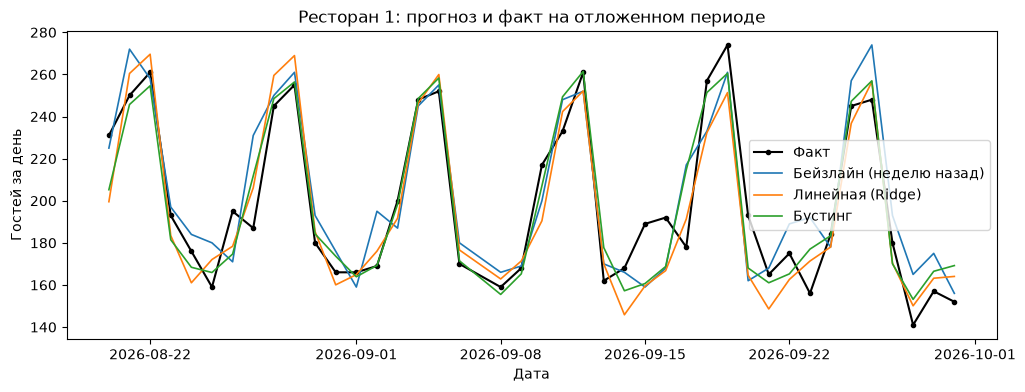

In [4]:
r1 = (valid_rows["restaurant_id"] == 1).to_numpy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(valid_rows.loc[r1, "date"], valid_rows.loc[r1, "guests"], "k-o", ms=3, label="Факт")
for name, pred in predictions.items():
    ax.plot(valid_rows.loc[r1, "date"], np.asarray(pred)[r1], lw=1.2, label=name)
ax.set_title("Ресторан 1: прогноз и факт на отложенном периоде")
ax.set_xlabel("Дата")
ax.set_ylabel("Гостей за день")
ax.legend()
plt.show()

In [5]:
ridge = linear.regressor_.named_steps["ridge"]
names = linear.regressor_.named_steps["preprocess"].get_feature_names_out()
effects = pd.Series((np.exp(ridge.coef_) - 1) * 100, index=names).round(1).sort_values()
effects

flags__is_jan1         -37.6
categories__dow_6       -7.9
levels__lag_21           1.4
categories__month_3      2.9
levels__lag_28           3.3
levels__lag_14           3.9
categories__dow_1        5.3
spread__roll_std_28      5.8
categories__dow_2        8.0
levels__lag_7            9.5
categories__dow_4       10.4
levels__roll_mean_28    10.7
categories__dow_3       11.4
categories__month_11    14.5
categories__dow_5       15.2
categories__month_2     16.1
categories__month_10    16.1
categories__month_9     16.4
flags__is_weekend       17.1
categories__month_7     17.3
categories__month_5     18.3
categories__month_6     19.0
categories__month_8     19.1
categories__month_4     20.6
categories__month_12    27.1
flags__is_holiday       29.1
dtype: float64

Так как модель обучена на логарифме числа гостей, коэффициенты читаются как процентные эффекты при прочих равных: праздник +29%, 1 января −38%, выходной (пт–вс) +17%. Эффекты дней недели и месяцев частично «делятся» с лагами: lag_7 уже несёт информацию о том же дне прошлой недели, поэтому отдельный коэффициент дня недели меньше, чем разница в недельном профиле из EDA.

In [6]:
errors = valid_rows[["date", "restaurant_id", "guests"]].copy()
errors["прогноз"] = linear.predict(valid_rows[FEATURE_COLUMNS]).round()
errors["ошибка"] = errors["прогноз"] - errors["guests"]
print(f"Средняя ошибка со знаком (смещение): {errors['ошибка'].mean():.1f} гостей")
errors.reindex(errors["ошибка"].abs().sort_values(ascending=False).index).head(5)

Средняя ошибка со знаком (смещение): -1.1 гостей


,date,restaurant_id,guests,прогноз,ошибка
688,2026-08-20,1,231.0,200.0,-31.0
714,2026-09-15,1,189.0,160.0,-29.0
719,2026-09-20,1,193.0,165.0,-28.0
709,2026-09-10,1,217.0,190.0,-27.0
1288,2026-09-10,2,124.0,98.0,-26.0


Систематического смещения нет (средняя ошибка со знаком около −1 гостя), модель одинаково часто ошибается вверх и вниз. Самые большие ошибки — около 30 гостей в обычные дни без праздников и закрытий. Это порядка двух стандартных отклонений случайного шума: у пуассоновского числа гостей при среднем ~190 разброс √190 ≈ 14. Значит, крупные ошибки — неустранимый случайный шум, а не пропущенная закономерность.